# Simulador de Epidemias (SIR)

##### Esse projeto tem por objetivo simular a evolução de uma doença ao longo do tempo. Primeiro, é preciso importar as bibliotecas que serão utilizadas: Numpy, Scipy e Mathplotlib.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

<p>Para começar a simulação, é necessário colocar as variáveis do cálculo de SIR: <br>
    
Suscetíveis (S): pessoas que podem contrair a doença.<br>
    
Infectados (I): pessoas que estão doentes e podem transmitir a doença.<br>

Recuperados/Removidos (R): pessoas que se recuperaram com imunidade ou morreram, não podendo mais transmitir a doença.</p>

População (N): número total da população.

Taxa de transmissão (beta): representa a taxa de trasmissão da doença.

Taxa de recuperação (gamma): representa a taxa de recuperação dos infectados.


In [2]:
N  = 212000000
I0 =  1000000 # infectados iniciais
R0 = 0 # recuperados 
S0 = N - I0 - R0 # fórmula para calcular os suscetíveis.

beta = 0.5
gamma = 0.1 

<p>O modelo é descrito por um sistema de equações diferenciais:

dS/dt = −βSI/N<br>

dI/dt = βSI/N − γI <br>

dR/dt= γI <br>

Com as equações, basta montar a função:</p>

In [3]:
def sir(y, t, N, beta, gamma):
    """
    Calcula as taxas de variações do sistema.

    Parâmetros:
    ----------
    y : tupla ou array
        Estado atual do sistema (S, I, R).
    t : int
        Tempo da simulação.
    N : int
        População total.
    beta : float
        Taxa de trasmissão.
    gamma : float
        Taxa de recuperação.

    Returns
    -------
    float
        Resultados das operações.
    """

    S, I, R = y 

    dSdt = -beta * S * I / N # taxa de variação dos suscetíveis.
    
    dIdt = beta * S * I / N - gamma * I # taxa de variação dos infectados
    
    dRdt = gamma * I # taxa de variação dos recuperados

    return dSdt, dIdt, dRdt

<p>A partir disso, criamos a variável de tempo t, que terá um intervalo de tempo de 160 dias, e o estado inicial do sistema y0. Com isso, criamos uma variável chamada resultado que irá realizar a função odeint(calcular as equações diferenciais), utilizando a função sir, o estado inicial y0, o período de tempo t e os argumentos N, beta e gamma.</p>

In [4]:
t = np.linspace(0, 160, 160) # período de tempo.

y0 = (S0, I0, R0) # estado inicial do sistema.

resultado = odeint( # resultado das equações.
    sir,
    y0,
    t,
    args=(N, beta, gamma)
)

S, I, R = resultado.T # irá criar uma matriz tansposta

<p>Com os cálculos prontos, agora é preciso plotar os gráficos utilizando a biblioteca matplotlib. Assim utilizamos diversas outras funções:

.figure - Tamanho do gráfico.<br>
.plot - Plotar o gráfico.<br>
.title - Título do gráfico.<br>
.xlabel - Nome do eixo X.<br>
.ylabel - Nome do eixo Y.<br>
.grid - Adiciona a grade no gráfico.<br>
.legend - Adiciona legenda no gráfico.<br>
.show - Mostra o gráfico na tela.
</p>

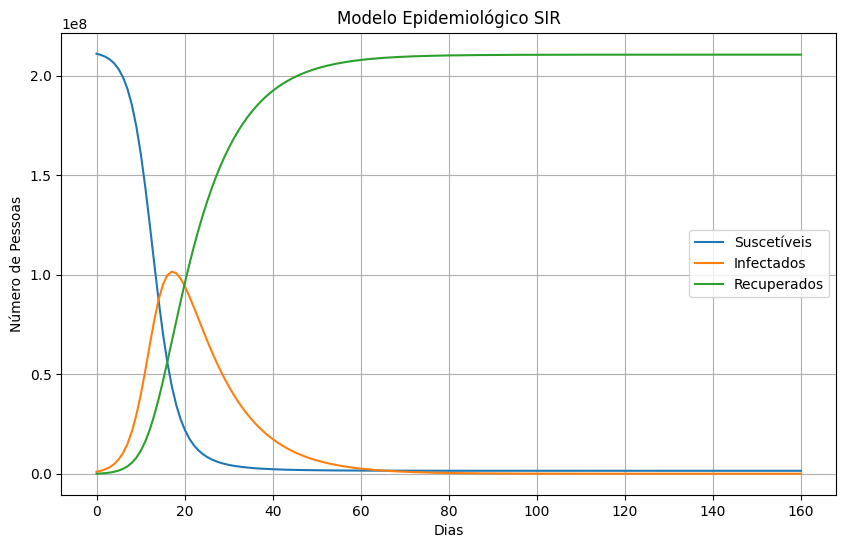

In [5]:
plt.figure(figsize=(10,6)) # tamanho do gráfico.

plt.plot(t, S, label="Suscetíveis") # plotar.
plt.plot(t, I, label="Infectados") # plotar.
plt.plot(t, R, label="Recuperados") # plotar.

plt.title("Modelo Epidemiológico SIR") # título.
plt.xlabel("Dias") # nome eixo x.
plt.ylabel("Número de Pessoas") # nome eixo y.

plt.grid(True) # grade.
plt.legend() # legenda.

plt.show() # mostrar gráfico.